In [1]:
import pandas as pd
import numpy as np

file_path = '../data/raw/shanghai_composite_yahoo.xlsx' 
data = pd.read_excel(file_path, sheet_name=0)  

# 查看数据
print(data.head())

# 添加技术指标
data['ma5'] = data['Close'].rolling(window=5).mean()  # 5日均线
data['ma10'] = data['Close'].rolling(window=10).mean()  # 10日均线
data['ma7.5'] = ( data['ma5'] + data['ma10'] )/2
data['rsi'] = data['Close'].diff().apply(lambda x: x if x > 0 else 0).rolling(window=14).mean() / \
              data['Close'].diff().abs().rolling(window=14).mean() * 100  # RSI
data['macd'] = data['Close'].ewm(span=12, adjust=False).mean() - data['Close'].ewm(span=26, adjust=False).mean()  # MACD

# 处理缺失值
data.dropna(inplace=True)

# 查看数据
print(data.head())

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 特征选择
X = data[['Open', 'High', 'Low', 'Volume', 'ma5', 'ma10', 'rsi', 'macd']]  # 特征
y = data['Close']  # 目标变量

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        Date     Open     High      Low    Close  Adj Close  Volume
0 2015-01-05  3258.63  3369.28  3253.88  3350.52    3350.52  531400
1 2015-01-06  3330.80  3394.22  3303.18  3351.45    3351.45  501700
2 2015-01-07  3326.65  3374.90  3312.21  3373.95    3373.95  391900
3 2015-01-08  3371.96  3381.57  3285.09  3293.46    3293.46  371100
4 2015-01-09  3276.97  3404.83  3267.51  3285.41    3285.41  410200
         Date     Open     High      Low    Close  Adj Close  Volume  \
14 2015-01-23  3357.10  3406.79  3328.29  3351.76    3351.76  366200   
15 2015-01-26  3347.26  3384.80  3321.31  3383.18    3383.18  317500   
16 2015-01-27  3389.85  3390.22  3290.22  3352.96    3352.96  374500   
17 2015-01-28  3325.72  3354.80  3294.66  3305.74    3305.74  301900   
18 2015-01-29  3259.00  3286.79  3234.24  3262.30    3262.30  274700   

         ma5      ma10      ma7.5        rsi       macd  
14  3261.622  3270.813  3266.2175  50.074117 -12.869110  
15  3314.988  3286.199  3300.5935  51.82985

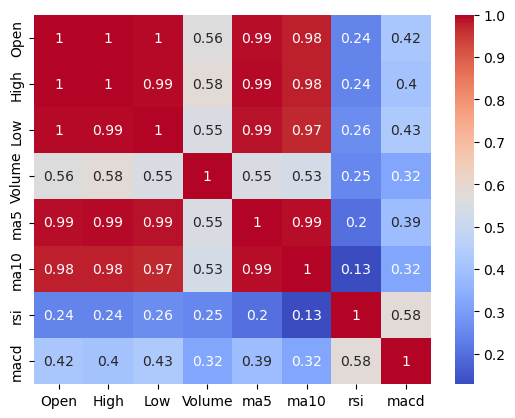

In [2]:
#判断共线性
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假设 df 是包含特征的数据集
features = ['Open', 'High', 'Low', 'Volume', 'ma5', 'ma10', 'rsi', 'macd']
corr_matrix = data[features].corr()

# 可视化
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

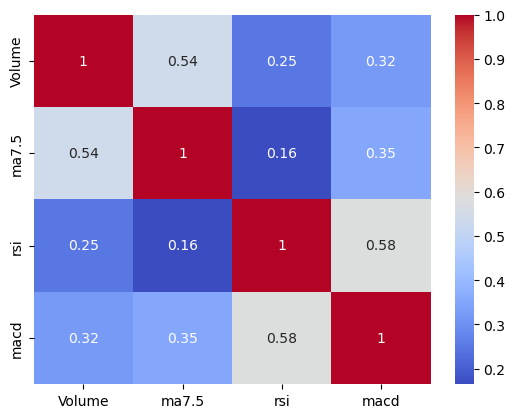

In [3]:
#判断共线性
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假设 df 是包含特征的数据集
features = ['Volume', 'ma7.5', 'rsi', 'macd']
corr_matrix = data[features].corr()

# 可视化
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [19]:
import pandas as pd
import numpy as np

file_path = '../data/raw/shanghai_composite_yahoo.xlsx' 
data = pd.read_excel(file_path, sheet_name=0)  

# 查看数据
print(data.head())

# 添加技术指标
data['ma5'] = data['Close'].rolling(window=5).mean()  # 5日均线
data['ma10'] = data['Close'].rolling(window=10).mean()  # 10日均线
data['ma7.5'] = ( data['ma5'] + data['ma10'] )/2
data['rsi'] = data['Close'].diff().apply(lambda x: x if x > 0 else 0).rolling(window=14).mean() / \
              data['Close'].diff().abs().rolling(window=14).mean() * 100  # RSI
data['macd'] = data['Close'].ewm(span=12, adjust=False).mean() - \
               data['Close'].ewm(span=26, adjust=False).mean()  # MACD

# 将目标变量调整为第二天的收盘价
data['Next_Close'] = data['Close'].shift(-1)
# 删除所有包含 NaN 的行
data.dropna(inplace=True)

# 查看数据
print(data.head())


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# 特征选择
X = data[['Volume', 'ma7.5', 'rsi', 'macd']]  # 特征
y = data['Next_Close']  # 目标变量

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        Date     Open     High      Low    Close  Adj Close  Volume
0 2015-01-05  3258.63  3369.28  3253.88  3350.52    3350.52  531400
1 2015-01-06  3330.80  3394.22  3303.18  3351.45    3351.45  501700
2 2015-01-07  3326.65  3374.90  3312.21  3373.95    3373.95  391900
3 2015-01-08  3371.96  3381.57  3285.09  3293.46    3293.46  371100
4 2015-01-09  3276.97  3404.83  3267.51  3285.41    3285.41  410200
         Date     Open     High      Low    Close  Adj Close  Volume  \
14 2015-01-23  3357.10  3406.79  3328.29  3351.76    3351.76  366200   
15 2015-01-26  3347.26  3384.80  3321.31  3383.18    3383.18  317500   
16 2015-01-27  3389.85  3390.22  3290.22  3352.96    3352.96  374500   
17 2015-01-28  3325.72  3354.80  3294.66  3305.74    3305.74  301900   
18 2015-01-29  3259.00  3286.79  3234.24  3262.30    3262.30  274700   

         ma5      ma10      ma7.5        rsi       macd  Next_Close  
14  3261.622  3270.813  3266.2175  50.074117 -12.869110     3383.18  
15  3314.988  3286.

In [5]:
#线性回归
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# 预测
y_pred = linear_model.predict(X_test)

# 获取系数和截距
coefficients = linear_model.coef_
intercept = linear_model.intercept_

# 打印系数
print("Linear 回归系数:", coefficients)
print("Linear 截距:", intercept)

# 打印回归公式
feature_names = ['Volume', 'ma7.5', 'rsi', 'macd']
formula = f"Close = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    formula += f" + {coef:.4f} * {feature_names[i]}"
print("Linear 回归公式:", formula)

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Linear Regression - Mean Squared Error: {mse}')
print(f'Linear Regression - R2 Score: {r2}')

Linear 回归系数: [ 10.4156054  315.08184689  29.90019081   8.2279331 ]
Linear 截距: 3199.813220605051
Linear 回归公式: Close = 3199.8132 + 10.4156 * Volume + 315.0818 * ma7.5 + 29.9002 * rsi + 8.2279 * macd
Linear Regression - Mean Squared Error: 3907.9467946620366
Linear Regression - R2 Score: 0.9631876130997111


In [4]:
#Lasso回归
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# 预测
y_pred = lasso_model.predict(X_test)

# 获取系数和截距
lasso_coefficients = lasso_model.coef_
lasso_intercept = lasso_model.intercept_

# 打印系数
print("Lasso 回归系数:", lasso_coefficients)
print("Lasso 截距:", lasso_intercept)

# 打印回归公式
lasso_formula = f"Close = {lasso_intercept:.4f}"
for i, coef in enumerate(lasso_coefficients):
    lasso_formula += f" + {coef:.4f} * {feature_names[i]}"
print("Lasso 回归公式:", lasso_formula)

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Lasso Regression - Mean Squared Error: {mse}')
print(f'Lasso Regression - R2 Score: {r2}')

Lasso 回归系数: [ 10.36404218 315.03099615  29.84319411   8.19446381]
Lasso 截距: 3199.8119112880067
Lasso 回归公式: Close = 3199.8119 + 10.3640 * Volume + 315.0310 * ma7.5 + 29.8432 * rsi + 8.1945 * macd
Lasso Regression - Mean Squared Error: 3906.7945062585763
Lasso Regression - R2 Score: 0.9631984675173267


In [5]:
#岭回归
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)  # alpha 是正则化强度
ridge_model.fit(X_train, y_train)

# 预测
y_pred = ridge_model.predict(X_test)

# 获取系数和截距
ridge_coefficients = ridge_model.coef_
ridge_intercept = ridge_model.intercept_

# 打印系数
print("岭回归系数:", ridge_coefficients)
print("岭回归截距:", ridge_intercept)

# 打印回归公式
ridge_formula = f"Close = {ridge_intercept:.4f}"
for i, coef in enumerate(ridge_coefficients):
    ridge_formula += f" + {coef:.4f} * {feature_names[i]}"
print("岭回归公式:", ridge_formula)

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Ridge Regression - Mean Squared Error: {mse}')
print(f'Ridge Regression - R2 Score: {r2}')

岭回归系数: [ 10.52207718 314.85528136  29.85472454   8.29181954]
岭回归截距: 3199.811566212457
岭回归公式: Close = 3199.8116 + 10.5221 * Volume + 314.8553 * ma7.5 + 29.8547 * rsi + 8.2918 * macd
Ridge Regression - Mean Squared Error: 3908.1172211113694
Ridge Regression - R2 Score: 0.9631860077031383


In [6]:
#二次多项式回归
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)

# 预测
y_pred = poly_model.predict(X_test)

# 获取多项式特征名称
poly_features = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(feature_names)

# 获取系数和截距
coefficients = poly_model.named_steps['linearregression'].coef_
intercept = poly_model.named_steps['linearregression'].intercept_

# 打印系数和截距
print("多项式回归系数:", coefficients)
print("多项式回归截距:", intercept)

# 组合成公式
formula = f"Close = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    if coef != 0:  # 只显示非零系数
        formula += f" + {coef:.4f} * {poly_features[i]}"
print("多项式回归公式:", formula)

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Polynomial Regression (Degree {degree}) - Mean Squared Error: {mse}')
print(f'Polynomial Regression (Degree {degree}) - R2 Score: {r2}')

多项式回归系数: [  0.           8.43968478 318.29250894  34.06262053  -2.30039555
   0.97402325   0.62037541  17.89340946  -8.5219832   -6.9283521
   4.93218741  12.32229232  -4.52162158  -7.92797949   3.05263703]
多项式回归截距: 3204.7291665286443
多项式回归公式: Close = 3204.7292 + 8.4397 * Volume + 318.2925 * ma7.5 + 34.0626 * rsi + -2.3004 * macd + 0.9740 * Volume^2 + 0.6204 * Volume ma7.5 + 17.8934 * Volume rsi + -8.5220 * Volume macd + -6.9284 * ma7.5^2 + 4.9322 * ma7.5 rsi + 12.3223 * ma7.5 macd + -4.5216 * rsi^2 + -7.9280 * rsi macd + 3.0526 * macd^2
Polynomial Regression (Degree 2) - Mean Squared Error: 3800.64336577762
Polynomial Regression (Degree 2) - R2 Score: 0.9641983984423408


In [7]:
#三次多项式回归
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

degree = 3
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)

# 预测
y_pred = poly_model.predict(X_test)

# 获取多项式特征名称
poly_features = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(feature_names)

# 获取系数和截距
coefficients = poly_model.named_steps['linearregression'].coef_
intercept = poly_model.named_steps['linearregression'].intercept_

# 打印系数和截距
print("多项式回归系数:", coefficients)
print("多项式回归截距:", intercept)

# 组合成公式
formula = f"Close = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    if coef != 0:  # 只显示非零系数
        formula += f" + {coef:.4f} * {poly_features[i]}"
print("多项式回归公式:", formula)

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Polynomial Regression (Degree {degree}) - Mean Squared Error: {mse}')
print(f'Polynomial Regression (Degree {degree}) - R2 Score: {r2}')

多项式回归系数: [-1.90517727e-14  7.28936730e+00  3.28131994e+02  3.14748714e+01
 -7.07551878e+00  4.56692477e+00 -1.04108791e+01  9.06902690e+00
  9.77674876e+00  6.02111107e-01 -5.31174147e+00  2.11265172e+01
 -7.85168892e+00  9.99607885e+00 -1.67126646e+01  3.15753183e-02
 -5.89170084e+00 -1.99643552e+00 -2.38500764e+00  9.68452420e+00
 -2.61787498e+00  3.67870857e+00 -1.82496078e+00 -6.92382156e-01
  1.29498896e+00 -4.81539058e+00  4.02457495e+00 -2.21831526e+00
 -6.23303810e-02 -9.59707873e+00  6.22673145e+00 -2.87586591e+00
  7.51675086e+00  8.30400218e+00 -6.27076471e+00]
多项式回归截距: 3203.977188484305
多项式回归公式: Close = 3203.9772 + -0.0000 * 1 + 7.2894 * Volume + 328.1320 * ma7.5 + 31.4749 * rsi + -7.0755 * macd + 4.5669 * Volume^2 + -10.4109 * Volume ma7.5 + 9.0690 * Volume rsi + 9.7767 * Volume macd + 0.6021 * ma7.5^2 + -5.3117 * ma7.5 rsi + 21.1265 * ma7.5 macd + -7.8517 * rsi^2 + 9.9961 * rsi macd + -16.7127 * macd^2 + 0.0316 * Volume^3 + -5.8917 * Volume^2 ma7.5 + -1.9964 * Volume^2 rs

In [8]:
#四次多项式回归
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

degree = 4
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)

# 预测
y_pred = poly_model.predict(X_test)

'''
# 获取多项式特征名称
poly_features = poly_model.named_steps['polynomialfeatures'].get_feature_names_out(feature_names)

# 获取系数和截距
coefficients = poly_model.named_steps['linearregression'].coef_
intercept = poly_model.named_steps['linearregression'].intercept_

# 打印系数和截距
print("多项式回归系数:", coefficients)
print("多项式回归截距:", intercept)

# 组合成公式
formula = f"Close = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    if coef != 0:  # 只显示非零系数
        formula += f" + {coef:.4f} * {poly_features[i]}"
print("多项式回归公式:", formula)
'''

# 评估
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Polynomial Regression (Degree {degree}) - Mean Squared Error: {mse}')
print(f'Polynomial Regression (Degree {degree}) - R2 Score: {r2}')

Polynomial Regression (Degree 4) - Mean Squared Error: 3411.835541269921
Polynomial Regression (Degree 4) - R2 Score: 0.9678609211985839


In [9]:
# 回归样条
# 定义截断幂基函数
def truncated_power_basis(x, knots, degree):
    return np.maximum(0, (x[:, None] - knots[None, :])) ** degree

# 选择分段点（knots）
knots = np.percentile(X_train[:, 0], [25, 50, 75])  # 以 Volume 为例，选择 25%, 50%, 75% 分位数作为分段点

# 添加截断幂基函数
degree = 3  # 选择三次多项式
X_train_spline = np.hstack([X_train, truncated_power_basis(X_train[:, 0], knots, degree)])
X_test_spline = np.hstack([X_test, truncated_power_basis(X_test[:, 0], knots, degree)])

# 拟合线性回归模型
model = LinearRegression()
model.fit(X_train_spline, y_train)

# 预测
y_pred = model.predict(X_test_spline)

# 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"回归样条的均方误差 (MSE): {mse}")
print(f'回归样条 - R2 Score: {r2}')

回归样条的均方误差 (MSE): 3962.153206895886
回归样条 - R2 Score: 0.9626769952421819


In [10]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import Pipeline

# 光滑样条
# 使用 SplineTransformer 和 RidgeCV
spline_transformer = SplineTransformer(degree=3, n_knots=5, include_bias=True)
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100))

# 构建管道
pipeline = Pipeline([
    ('spline', spline_transformer),
    ('ridge', ridge_cv)
])

# 拟合模型
pipeline.fit(X_train, y_train)

# 预测
y_pred = pipeline.predict(X_test)

# 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"光滑样条的均方误差 (MSE): {mse}")
print(f'光滑样条 - R2 Score: {r2}')

光滑样条的均方误差 (MSE): 3895.1454954047526
光滑样条 - R2 Score: 0.9633081997928896


In [18]:
from statsmodels.tsa.ar_model import AutoReg

#自回归AR
# 选择合适的滞后阶数
from statsmodels.tsa.ar_model import ar_select_order

# 选择滞后阶数
selected_lag = ar_select_order(data['Close'], maxlag=10)
print(f"Selected lag: {selected_lag.ar_lags}")

# 拟合自回归模型
model = AutoReg(data['Close'], lags=selected_lag.ar_lags)
model_fit = model.fit()

# 预测
predictions = model_fit.predict(start=len(data['Close']), end=len(data['Close']) + len(data['Close']) - 1, dynamic=False)

# 评估模型
mse = mean_squared_error(data['Close'], predictions[:len(data['Close'])])
r2 = r2_score(data['Close'], predictions[:len(data['Close'])])
print(f"AR Model MSE: {mse}")
print(f'AR Model - R2 Score: {r2}')

Selected lag: [1, 2]
AR Model MSE: 109211.16425401326
AR Model - R2 Score: 0.04012410204497108


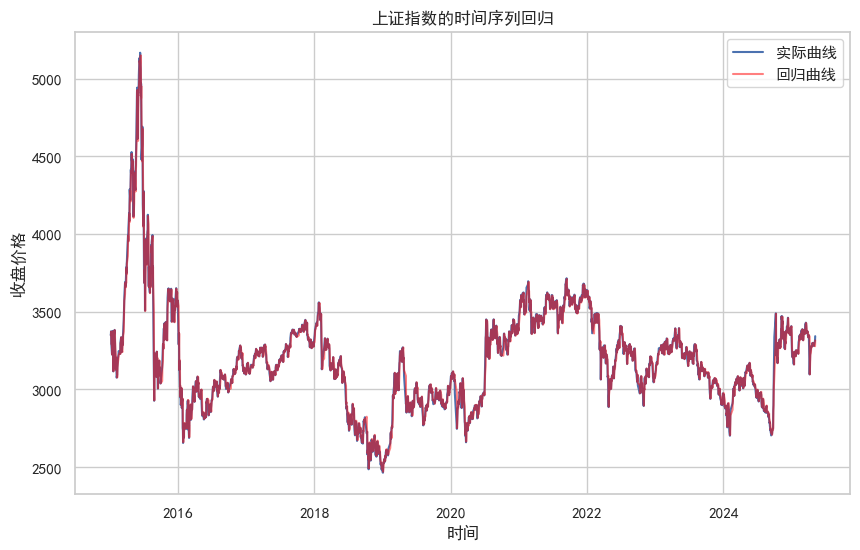

In [16]:
import statsmodels.api as sm

# Read data from CSV
data = pd.read_excel('../data/raw/shanghai_composite_yahoo.xlsx')

# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])


# Set the Date column as the index of the DataFrame
data.set_index('Date', inplace=True)

# Select the 'Close' column for the AR(1) model
y = data['Close']

# Fit AR(1) model
# Note: order=(1,0,0) specifies an AR(1) model
model = sm.tsa.ARIMA(y, order=(1, 0, 0))
fitted_model = model.fit()

# Make predictions
# We'll predict the last 10 days to see how our model performs
predictions = fitted_model.predict(start=1, end=len(y)-1)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='实际曲线')
plt.plot(predictions, color='red', label='回归曲线', alpha=0.5)
plt.title('上证指数的时间序列回归')
plt.xlabel('时间')
plt.ylabel('收盘价格')
plt.legend()
plt.show()


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 拟合带有外生变量的自回归模型
model = SARIMAX(data['Close'], exog=X, order=(selected_lag.ar_lags, 0, 0))
model_fit = model.fit(disp=False)

# 预测
predictions = model_fit.predict(start=len(data['Close']), end=len(data['Close']) + len(data['Close']) - 1, exog=X)

# 评估模型
mse = mean_squared_error(data['Close'], predictions[:len(data['Close'])])
r2 = r2_score(data['Close'], predictions[:len(data['Close'])])
print(f"ARX Model MSE: {mse}")
print(f'ARX Model - R2 Score: {r2}')

ARX Model MSE: 2541.428795568934
ARX Model - R2 Score: 0.9776629407451276


In [16]:
#结果对比
results = {
    'Linear Regression': [mean_squared_error(y_test, LinearRegression().fit(X_train, y_train).predict(X_test)), 
                          r2_score(y_test, LinearRegression().fit(X_train, y_train).predict(X_test))],
    'Lasso Regression': [mean_squared_error(y_test, Lasso(alpha=0.1).fit(X_train, y_train).predict(X_test)), 
                         r2_score(y_test, Lasso(alpha=0.1).fit(X_train, y_train).predict(X_test))],
    'Ridge Regression': [mean_squared_error(y_test, Ridge(alpha=1.0).fit(X_train, y_train).predict(X_test)), 
                         r2_score(y_test, Ridge(alpha=1.0).fit(X_train, y_train).predict(X_test))],
    'Polynomial Regression_Degree 2': [mean_squared_error(y_test, make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_train, y_train).predict(X_test)), 
                              r2_score(y_test, make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_train, y_train).predict(X_test))],
    'Polynomial Regression_Degree 3': [mean_squared_error(y_test, make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(X_train, y_train).predict(X_test)), 
                              r2_score(y_test, make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(X_train, y_train).predict(X_test))],
    'Polynomial Regression_Degree 4': [mean_squared_error(y_test, make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(X_train, y_train).predict(X_test)), 
                              r2_score(y_test, make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(X_train, y_train).predict(X_test))]
}

results_df = pd.DataFrame(results, index=['Mean Squared Error', 'R2 Score'])
print(results_df)

                    Linear Regression  Lasso Regression  Ridge Regression  \
Mean Squared Error        1680.641303       1680.639233       1680.641365   
R2 Score                     0.983496          0.983496          0.983496   

                    Polynomial Regression_Degree 2  \
Mean Squared Error                     1622.724632   
R2 Score                                  0.984064   

                    Polynomial Regression_Degree 3  \
Mean Squared Error                     1663.720012   
R2 Score                                  0.983662   

                    Polynomial Regression_Degree 4  
Mean Squared Error                     1786.073568  
R2 Score                                  0.982460  
